# Task 4 — The Transformer Architecture

### The Full Encoder-Decoder Stack
The **Transformer** completely discards recurrent connections, relying entirely on self-attention mechanisms to map inputs to outputs.

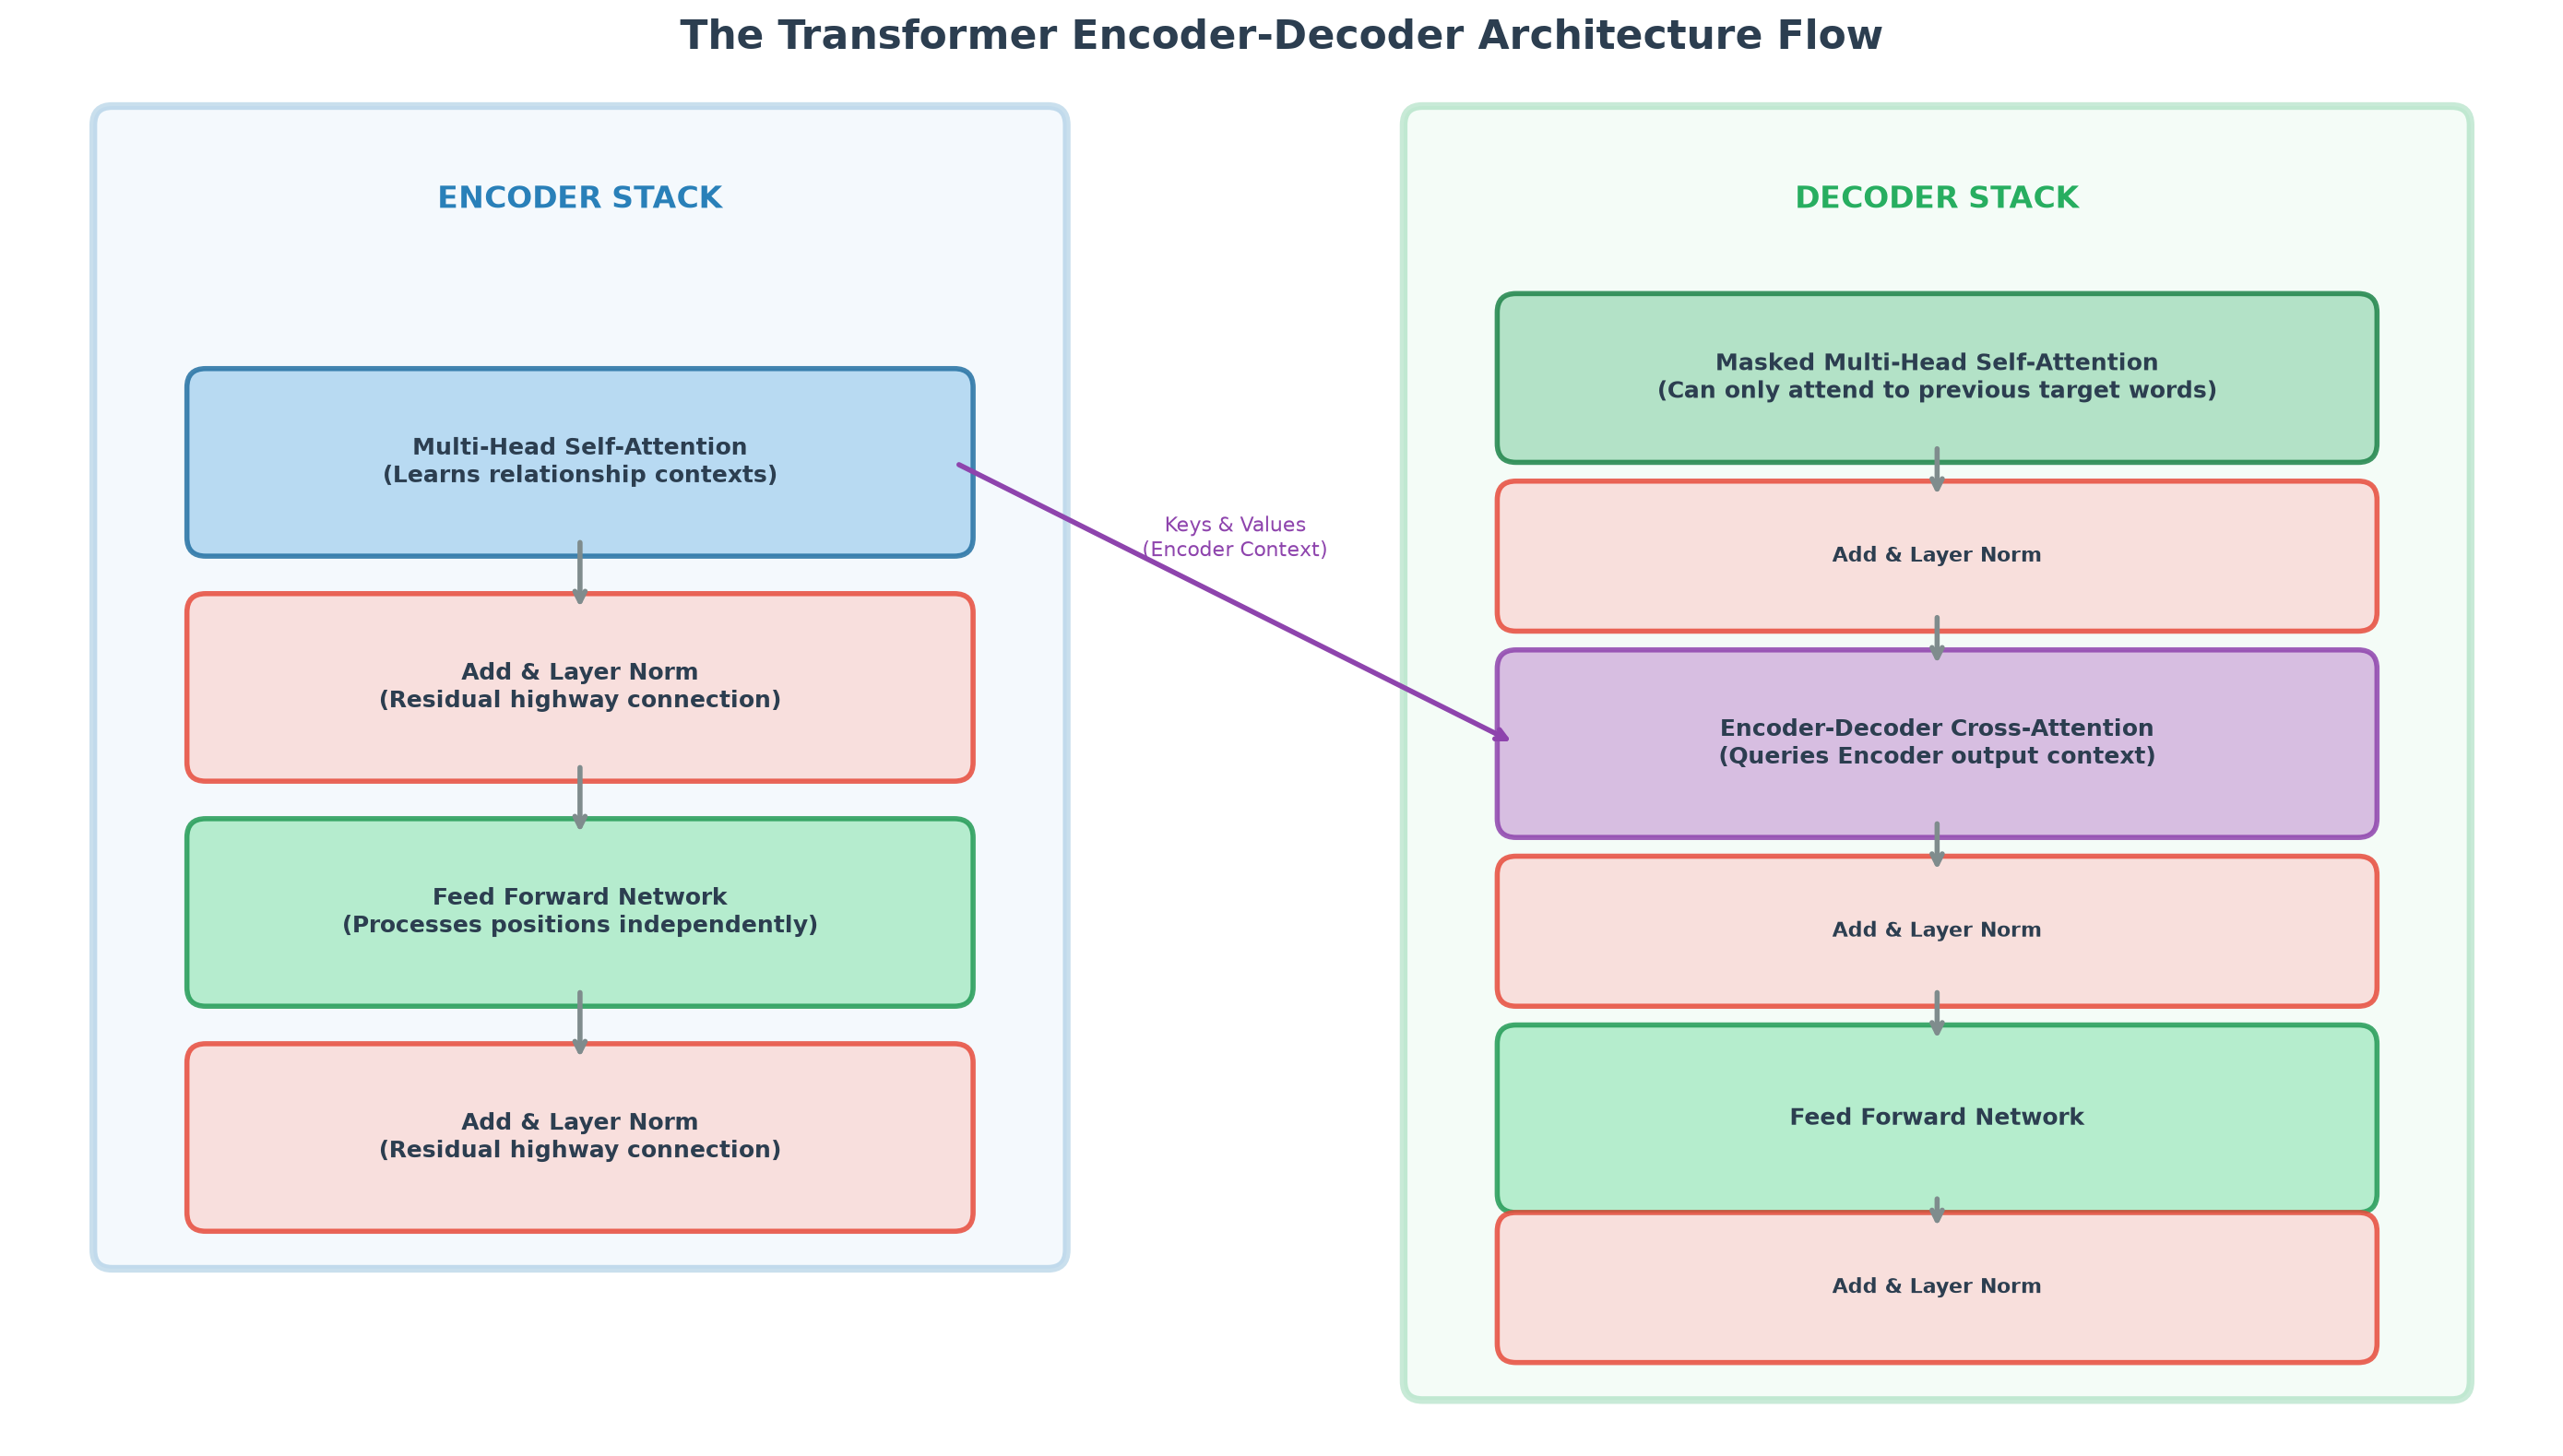

### 1. The Encoder Block
The Encoder's job is to generate rich semantic contextual representations of the input sequence. Each layer in the encoder stack contains two main sub-layers:
- **Multi-Head Self-Attention**: Computes self-attention across input tokens in parallel.
- **Position-wise Feed-Forward Network (FFN)**: Applies a simple 2-layer linear projection with ReLU activation to each position independently.

### 2. The Decoder Block
The Decoder's job is to predict target tokens autoregressively. Each layer in the decoder stack contains three sub-layers:
- **Masked Multi-Head Self-Attention**: Prevents the decoder from "looking ahead" at future target tokens during training (cheating) by masking future positions.
- **Encoder-Decoder Cross-Attention**: The decoder acts as Query ($Q$), while the Encoder output acts as Keys ($K$) and Values ($V$). This allows the decoder to extract translation context from the source sentence.
- **Position-wise Feed-Forward Network**: Projects output hidden dimensions.

---

### Multi-Head Attention: Parallel Learning Heads
Rather than calculating a single attention weight mapping, the Transformer splits the Queries, Keys, and Values into $h$ separate chunks and projects them in parallel. This is called **Multi-Head Attention**.

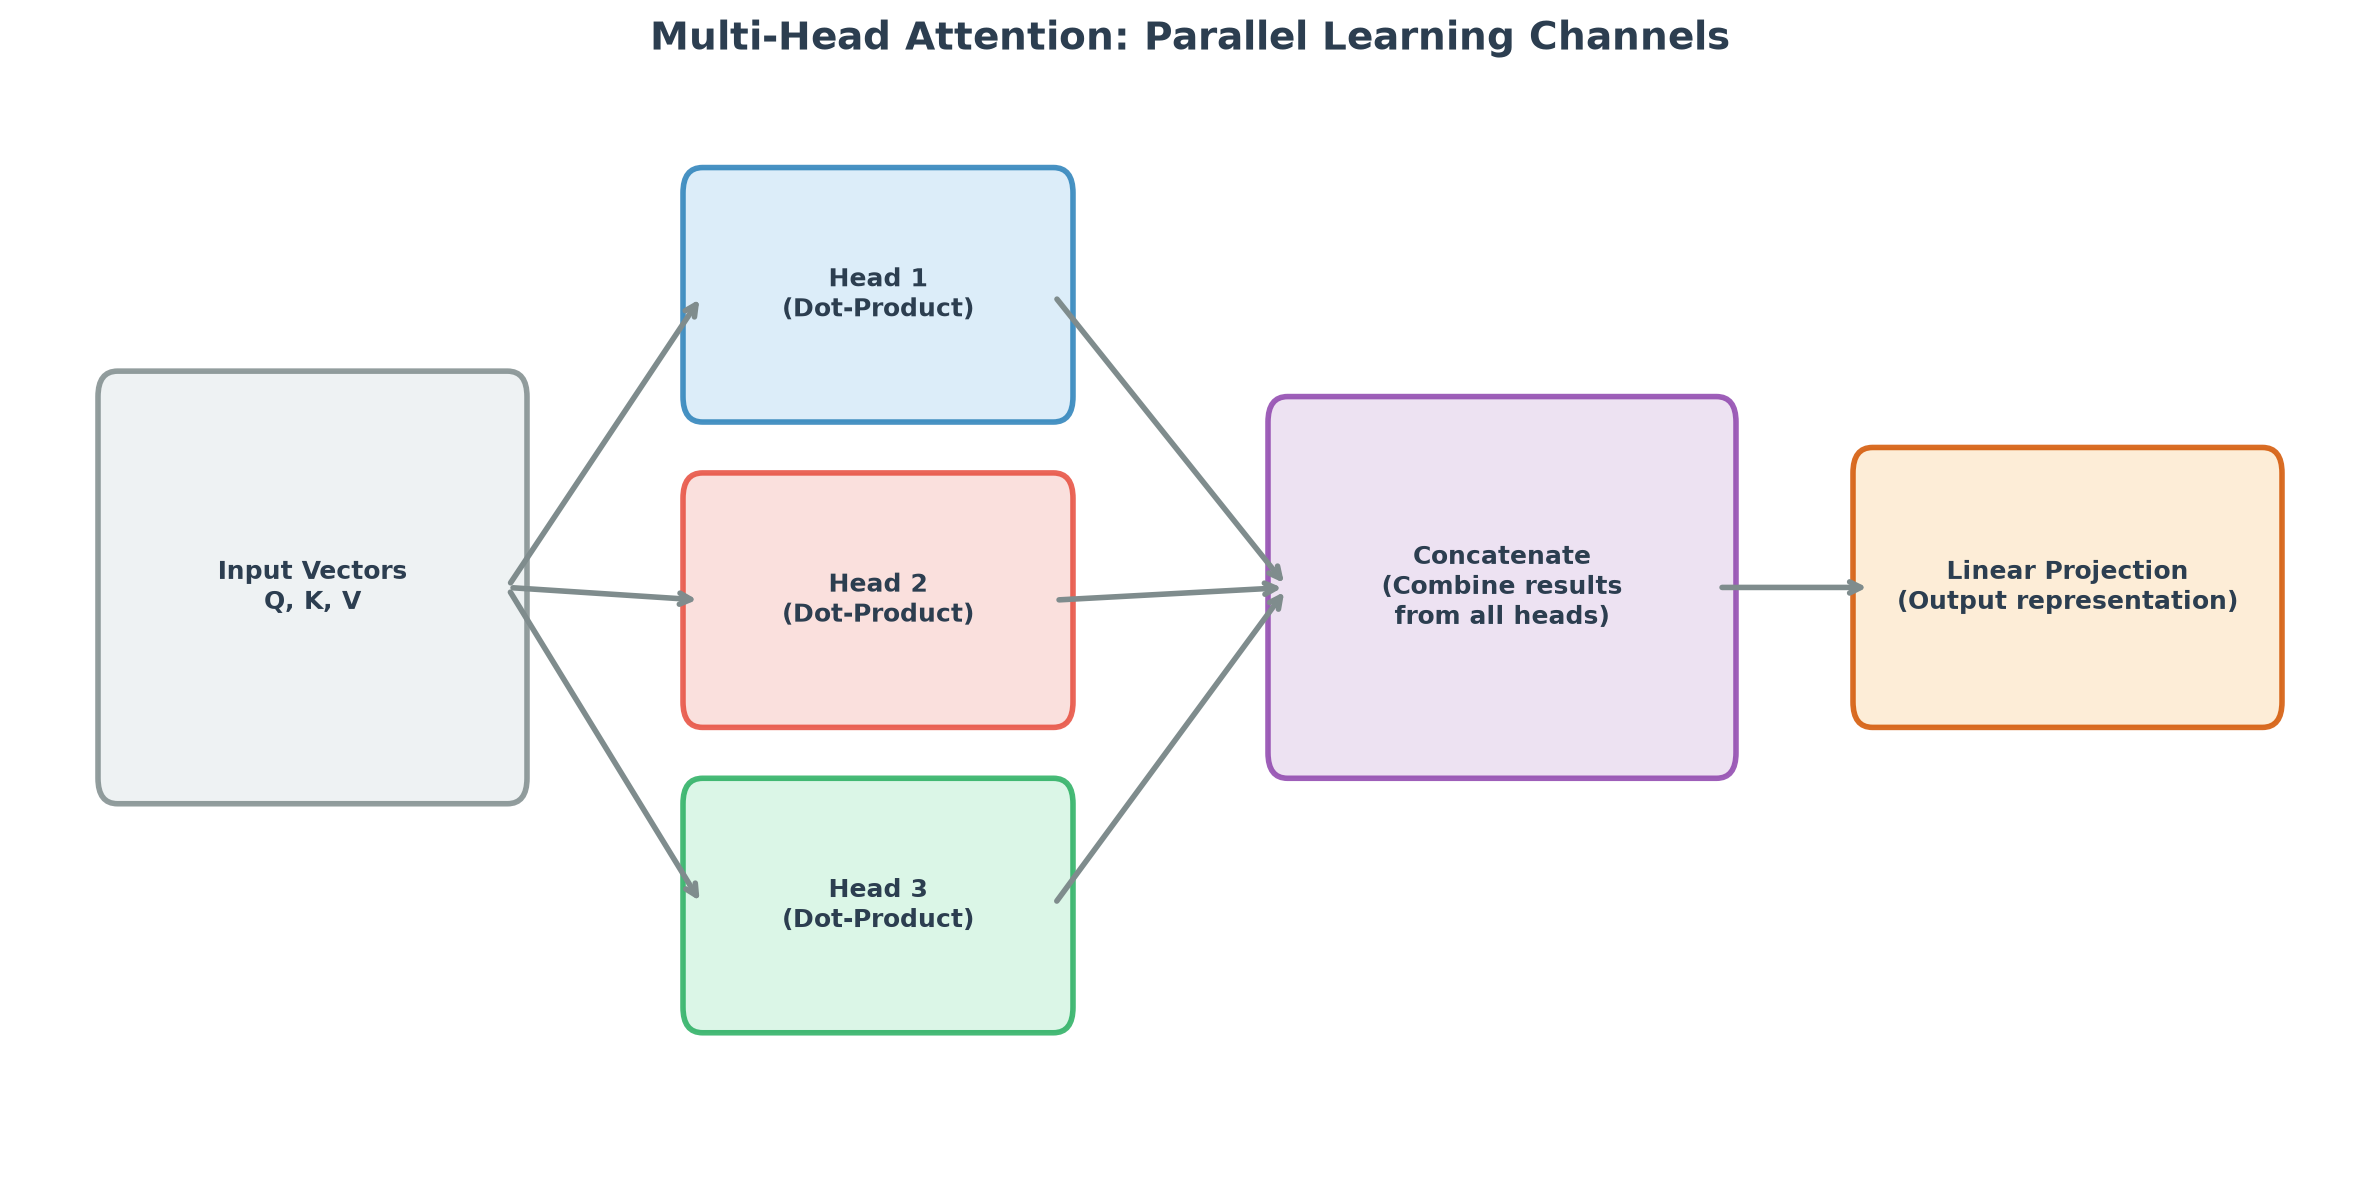

This division allows the model to learn multiple relationship structures simultaneously (e.g., one head focuses on subject-verb syntax relationships, while another focuses on semantic pronoun resolutions).

---

### Causal Masking (Masked Attention)
During training, the decoder receives the entire target sentence. To prevent self-attention from attending to words that occur in the future, we apply a **Causal Mask**.

This mask replaces future scores with negative infinity ($-\infty$) before passing them to the Softmax function, converting future weights to exactly $0.0$.

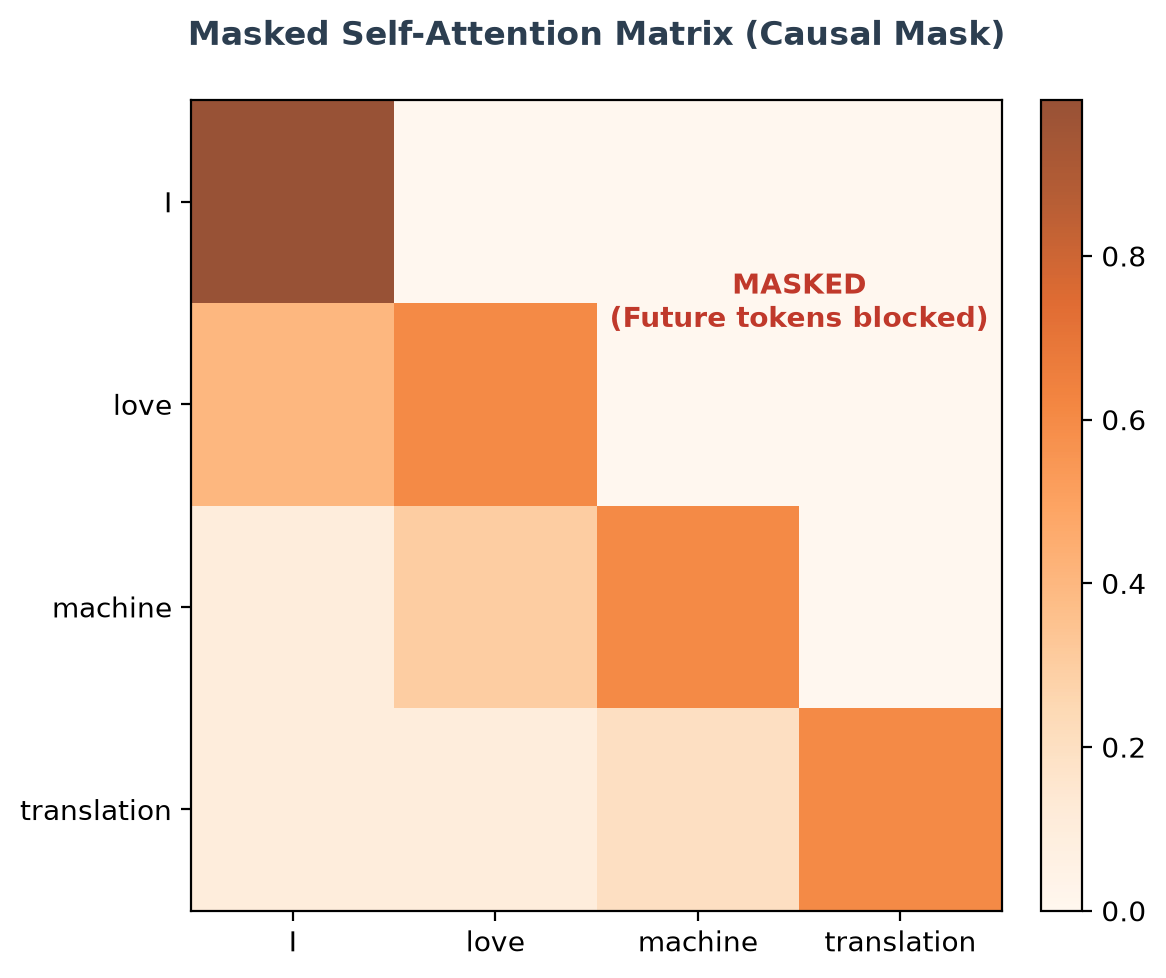

---

### Residual Connections & Layer Normalization
To support deep neural stacks (typically 6 layers deep, up to hundreds in modern LLMs) without vanishing or exploding gradients, the Transformer utilizes **Residual Connections** and **Layer Normalization**.

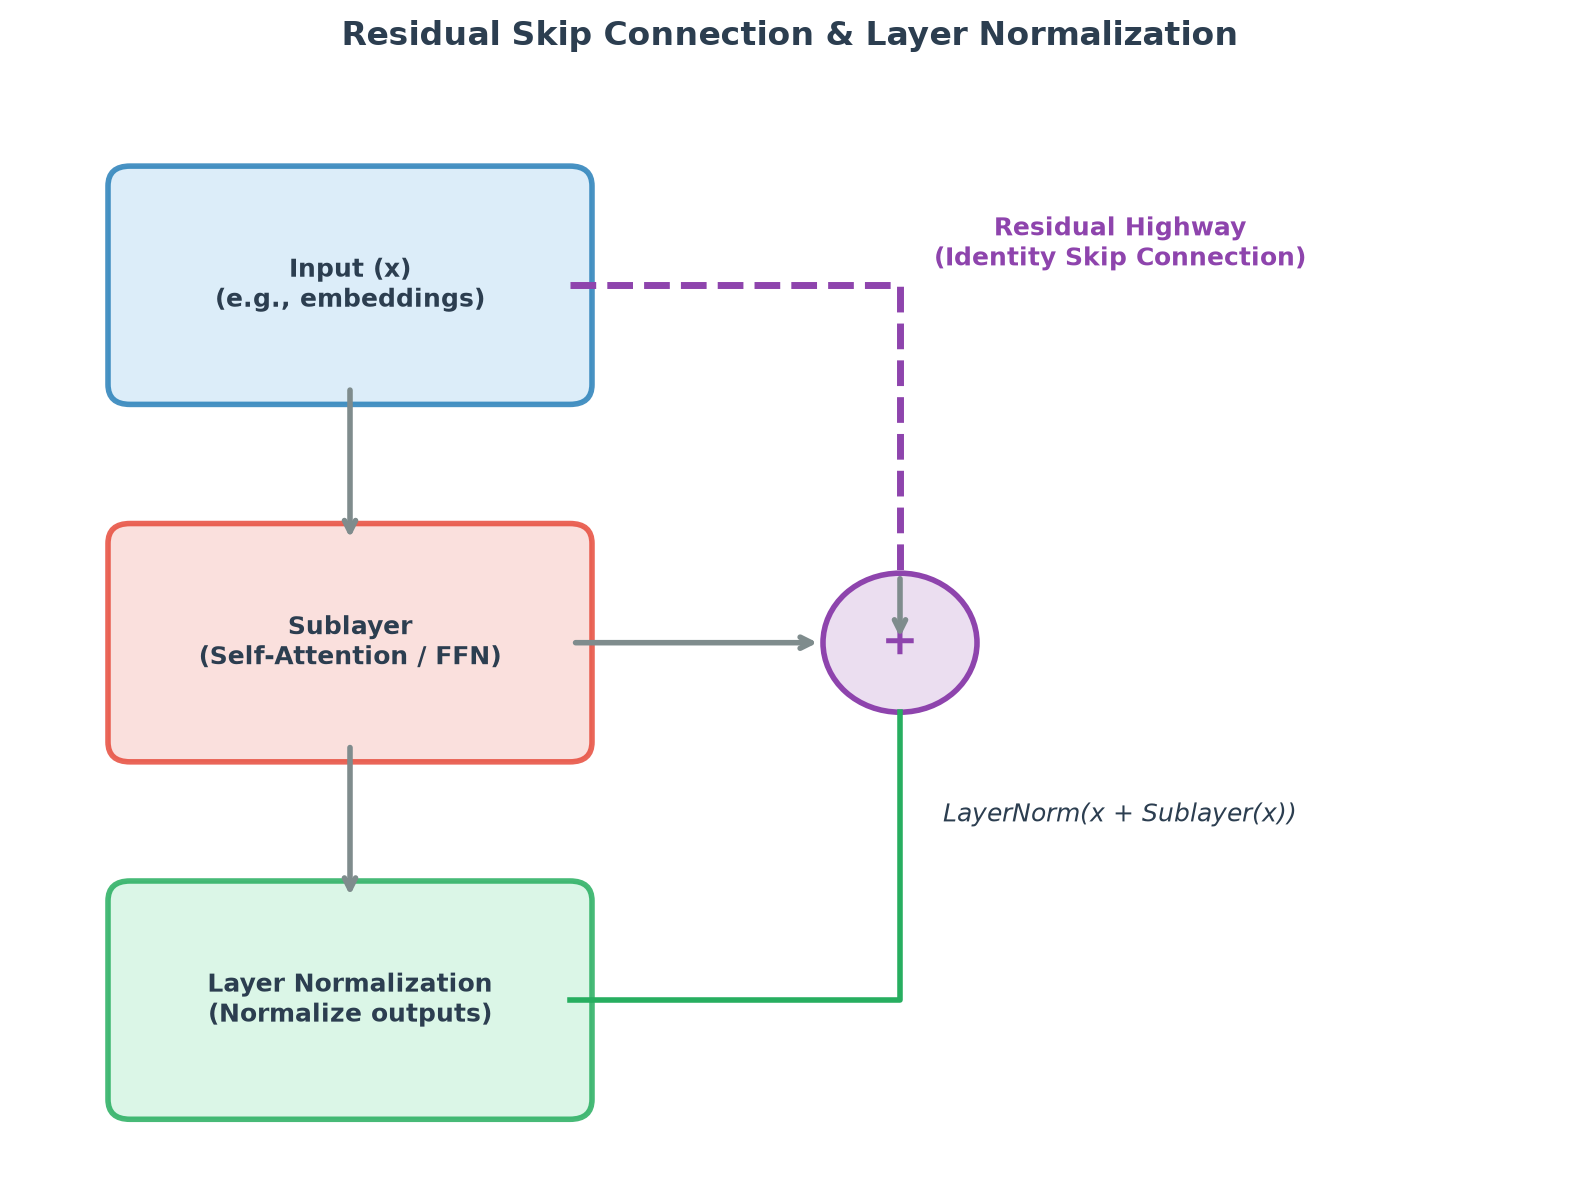

The input $x$ is carried over via a skip connection and added directly to the sub-layer output before Layer Normalization is applied:
$$\text{Output} = \text{LayerNorm}(x + \text{SubLayer}(x))$$
